Files processed: 550
list_freqs: 550
list_triplets: 550
Temperature points in plot range (Open_air): 1101
Temperature points in plot range (1762nm_box): 1101
Temperature binning (minutes): 5


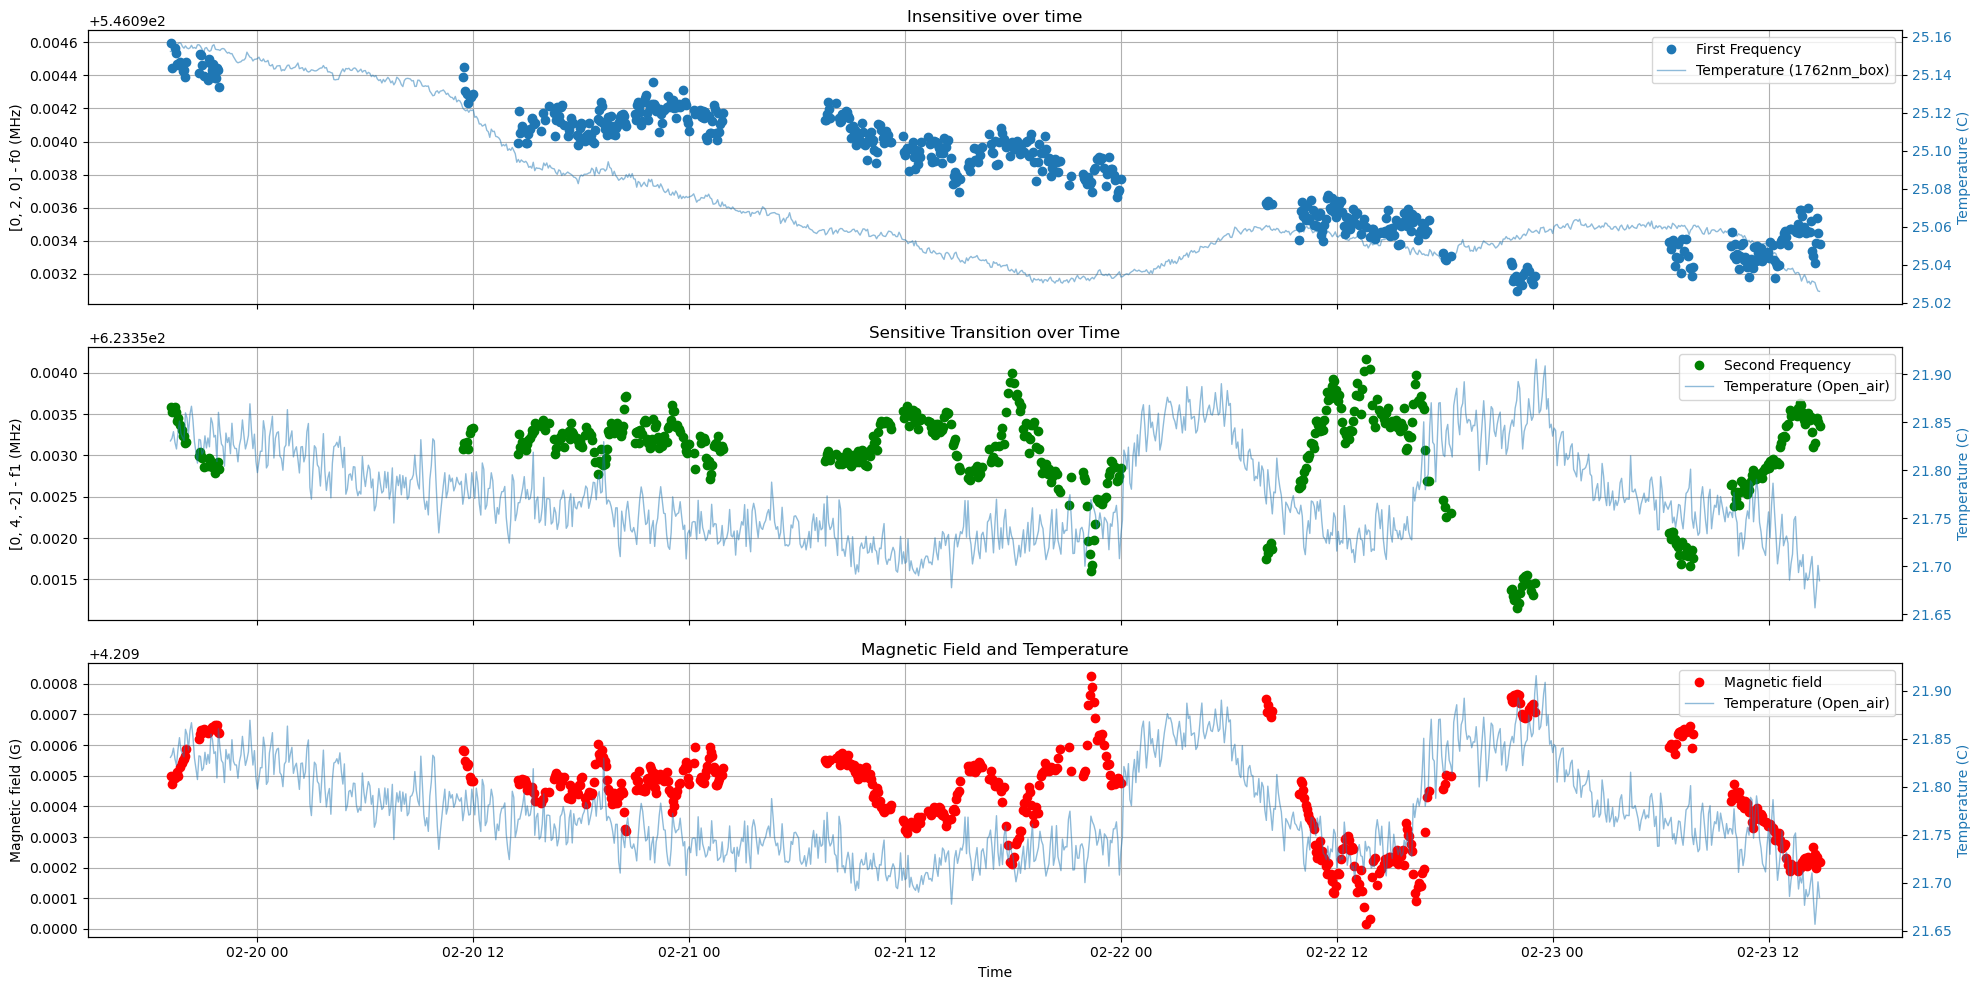

In [4]:
import os
import re
import json
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np

# Define the folders containing the files
folder_paths = [
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_Ramsey_calibrations",
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_bussed_Ramsey_daily_calibrations",
]

# Temperature log folders
temp_base_folder_default = r"Z:\Lab_HPT_logs\Open_air"
temp_base_folder_top_insensitive = r"Z:\Lab_HPT_logs\1762nm_box"
TEMP_BIN_MINUTES = 5  # Set to None, 1, or 5

# Define date-time filter (Modify as needed)
start_date = datetime(2026, 2, 19, 16, 0, 0)  # Change to desired start datetime
end_date = datetime(2026, 12, 15, 0, 0, 59)  # Change to desired end datetime (Optional)

temp_line_pattern = re.compile(
    r"^(?P<time>\d{2}:\d{2}:\d{2})\s*-\s*.*?\bAvg Temp:\s*(?P<temp>[-+]?\d*\.?\d+)"
)
temperature_cache = {}


def load_temperature_for_day(day_dt, base_folder):
    """Load one day of temperature logs from YYYY_MM/YYYY_MM_DD[.txt]."""
    cache_key = (base_folder, day_dt.date())
    if cache_key in temperature_cache:
        return temperature_cache[cache_key]

    month_dir = os.path.join(base_folder, day_dt.strftime("%Y_%m"))
    day_stem = day_dt.strftime("%Y_%m_%d")
    day_candidates = [
        os.path.join(month_dir, day_stem),
        os.path.join(month_dir, f"{day_stem}.txt"),
    ]

    day_file = next((path for path in day_candidates if os.path.isfile(path)), None)
    if day_file is None:
        temperature_cache[cache_key] = ([], [])
        return temperature_cache[cache_key]

    day_times = []
    day_temps = []

    with open(day_file, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            match = temp_line_pattern.search(line.strip())
            if not match:
                continue

            try:
                sample_time = datetime.strptime(match.group("time"), "%H:%M:%S").time()
                sample_dt = datetime.combine(day_dt.date(), sample_time)
                sample_temp = float(match.group("temp"))
            except ValueError:
                continue

            day_times.append(sample_dt)
            day_temps.append(sample_temp)

    if day_times:
        paired = sorted(zip(day_times, day_temps), key=lambda x: x[0])
        day_times, day_temps = map(list, zip(*paired))
    else:
        day_times, day_temps = [], []

    temperature_cache[cache_key] = (day_times, day_temps)
    return temperature_cache[cache_key]


def load_temperature_series(start_dt, end_dt, base_folder):
    """Load all temperature samples in the [start_dt, end_dt] range."""
    if start_dt is None or end_dt is None or end_dt < start_dt:
        return np.array([], dtype=object), np.array([], dtype=float)

    all_times = []
    all_temps = []

    current_day = start_dt.date()
    last_day = end_dt.date()

    while current_day <= last_day:
        day_dt = datetime.combine(current_day, datetime.min.time())
        day_times, day_temps = load_temperature_for_day(day_dt, base_folder)

        if day_times:
            for t, temp in zip(day_times, day_temps):
                if start_dt <= t <= end_dt:
                    all_times.append(t)
                    all_temps.append(temp)

        current_day += timedelta(days=1)

    return np.array(all_times, dtype=object), np.array(all_temps, dtype=float)


def bin_temperature_series(temp_times, temp_values, bin_minutes=None):
    """Bin temperature points into fixed-minute bins using mean temperature."""
    if bin_minutes is None:
        return temp_times, temp_values

    if bin_minutes not in (1, 5):
        raise ValueError("TEMP_BIN_MINUTES must be None, 1, or 5")

    if temp_values.size == 0:
        return temp_times, temp_values

    bins = {}
    for t, temp in zip(temp_times, temp_values):
        floored_minute = (t.minute // bin_minutes) * bin_minutes
        bin_dt = t.replace(minute=floored_minute, second=0, microsecond=0)
        bins.setdefault(bin_dt, []).append(float(temp))

    binned_times = sorted(bins.keys())
    binned_values = [np.mean(bins[bt]) for bt in binned_times]
    return np.array(binned_times, dtype=object), np.array(binned_values, dtype=float)


# Lists to store the extracted data
list_freqs = []
list_triplets = []
file_times = []

# Iterate through all files in both folders
for folder_path in folder_paths:
    if not os.path.isdir(folder_path):
        print(f"Skipping missing folder: {folder_path}")
        continue

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        # Skip if not a file
        if not os.path.isfile(file_path):
            continue

        # Get file modification time
        mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))

        # Check if the file is within the date-time range
        if start_date <= mod_time <= end_date:
            file_times.append(mod_time)

            # Read the file and process its contents
            with open(file_path, "r") as file:
                try:
                    lines = file.readlines()
                    bottom_list = json.loads(lines[1].strip())
                    list_triplets.append(bottom_list)
                    top_list = json.loads(lines[0].strip())
                    list_freqs.append(top_list)
                except (IndexError, json.JSONDecodeError) as e:
                    print(f"Error processing file {file_path}: {e}")


# Display the results
print("Files processed:", len(file_times))
print("list_freqs:", len(list_freqs))
print("list_triplets:", len(list_triplets))

# Sort data by modification time
sorted_data = sorted(zip(file_times, list_freqs), key=lambda x: x[0])
sorted_times, sorted_freqs = zip(*sorted_data) if sorted_data else ([], [])

# Extract first and second frequency values
first_freq_values = [freq[0] for freq in sorted_freqs if len(freq) > 1]
second_freq_values = [freq[1] for freq in sorted_freqs if len(freq) > 1]

num_points = min(len(sorted_times), len(first_freq_values), len(second_freq_values))
sorted_times = list(sorted_times[:num_points]) if num_points else []
first_freq_values = np.array(first_freq_values[:num_points], dtype=float)
second_freq_values = np.array(second_freq_values[:num_points], dtype=float)

# Compute the magnetic field from frequency differences
if num_points > 0:
    freq_differences = (second_freq_values - first_freq_values) / (-3.498)
    freq_differences = 4.2095 + freq_differences - freq_differences[0]

    # Compute slope dB/dt
    time_seconds = np.array([(t - sorted_times[0]).total_seconds() for t in sorted_times], dtype=float)
    dB_dt = np.gradient(freq_differences, time_seconds) if num_points > 1 else np.array([0.0])
else:
    freq_differences = np.array([])
    time_seconds = np.array([])
    dB_dt = np.array([])

# Define what "big slope" means (tune this!)
slope_threshold = np.std(dB_dt) * 0.8 if dB_dt.size else 0.0
large_slope_mask = np.abs(dB_dt) > slope_threshold if dB_dt.size else np.array([], dtype=bool)
bad_time_mask = large_slope_mask
good_time_mask = ~bad_time_mask

# Find contiguous regions where slope is large
regions = []
start_idx = None

for i, val in enumerate(large_slope_mask):
    if val and start_idx is None:
        start_idx = i
    elif not val and start_idx is not None:
        regions.append((start_idx, i - 1))
        start_idx = None

if start_idx is not None:
    regions.append((start_idx, len(large_slope_mask) - 1))

# Load temperature points within plotted x-range
if sorted_times:
    temp_times_default, temp_values_default = load_temperature_series(
        sorted_times[0], sorted_times[-1], temp_base_folder_default
    )
    temp_times_top, temp_values_top = load_temperature_series(
        sorted_times[0], sorted_times[-1], temp_base_folder_top_insensitive
    )
else:
    temp_times_default, temp_values_default = np.array([], dtype=object), np.array([], dtype=float)
    temp_times_top, temp_values_top = np.array([], dtype=object), np.array([], dtype=float)

temp_times_default, temp_values_default = bin_temperature_series(
    temp_times_default, temp_values_default, TEMP_BIN_MINUTES
)
temp_times_top, temp_values_top = bin_temperature_series(
    temp_times_top, temp_values_top, TEMP_BIN_MINUTES
)

print("Temperature points in plot range (Open_air):", len(temp_times_default))
print("Temperature points in plot range (1762nm_box):", len(temp_times_top))
print("Temperature binning (minutes):", TEMP_BIN_MINUTES)

# Create a single figure with subplots
fig, ax = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

# Plot first frequency vs. time
ax[0].plot(sorted_times, first_freq_values, "o", label="First Frequency")
ax[0].set_ylabel("[0, 2, 0] - f0 (MHz)")
ax[0].set_title("Insensitive over time")
ax[0].grid(True)

# Plot second frequency vs. time
ax[1].plot(sorted_times, second_freq_values, "go", label="Second Frequency")
ax[1].set_ylabel("[0, 4, -2] - f1 (MHz)")
ax[1].set_title("Sensitive Transition over Time")
ax[1].grid(True)

# Plot magnetic field vs. time
ax[2].plot(sorted_times, freq_differences, "o", color="r", label="Magnetic field")
ax[2].set_xlabel("Time")
ax[2].set_ylabel("Magnetic field (G)")
ax[2].set_title("Magnetic Field and Temperature")
ax[2].grid(True)

# Plot temperature on right y-axis for all 3 subplots
temp_color = "tab:blue"
ax_temp = []
for i, axis in enumerate(ax):
    temp_axis = axis.twinx()

    if i == 0:
        t_times = temp_times_top
        t_vals = temp_values_top
        t_label = "Temperature (1762nm_box)"
    else:
        t_times = temp_times_default
        t_vals = temp_values_default
        t_label = "Temperature (Open_air)"

    if t_vals.size:
        temp_axis.plot(
            t_times,
            t_vals,
            "-",
            color=temp_color,
            linewidth=1,
            alpha=0.5,
            label=t_label,
        )

    temp_axis.set_ylabel("Temperature (C)", color=temp_color)
    temp_axis.tick_params(axis="y", labelcolor=temp_color)
    ax_temp.append(temp_axis)

# Combine legends from both y-axes on each subplot
for i, axis in enumerate(ax):
    lines_left, labels_left = axis.get_legend_handles_labels()
    lines_right, labels_right = ax_temp[i].get_legend_handles_labels()
    if lines_left or lines_right:
        axis.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

# Shade regions on all subplots
# for start, end in regions:
#     t_start = sorted_times[start]
#     t_end = sorted_times[end]
#     for axis in ax:
#         axis.axvspan(t_start, t_end, alpha=0.3, color='gray')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plots
plt.tight_layout()
plt.savefig("freq_deviation_over_time.png")
plt.show()



Files processed: 705


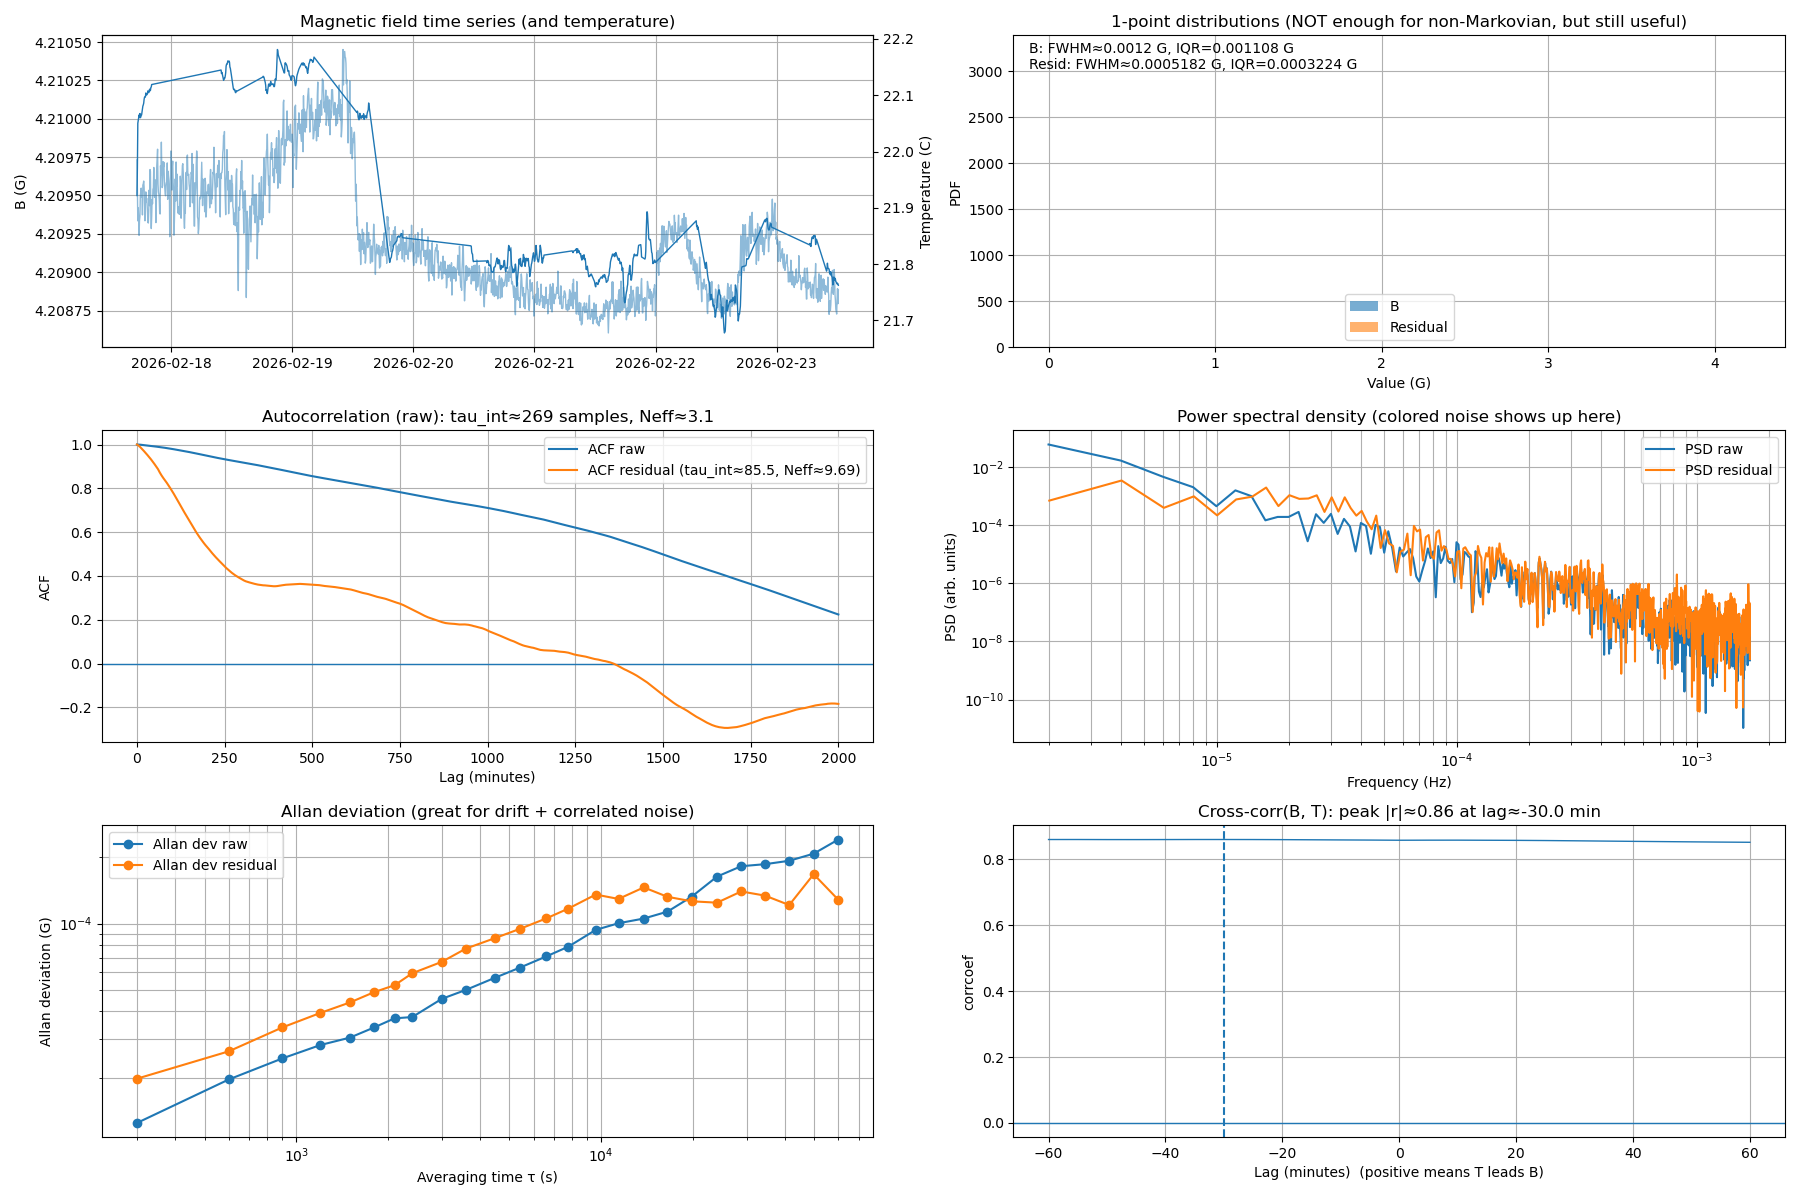


=== Raw B noise (uniform grid) ===
Samples: 1669  dt=300s
Std(B): 0.000543514 G
tau_int(raw): 269.389 samples  => Neff≈3.09775
FWHM_like(B): 0.00120045 G  |  IQR(B): 0.00110809 G

=== Residual after temp model ===
Std(resid): 0.000256185 G
tau_int(resid): 85.4875 samples  => Neff≈9.69147
FWHM_like(resid): 0.000518236 G  |  IQR(resid): 0.000322358 G

Temp model coefficients (first few):
[4.10927360e+00 6.42573139e-04 2.13042491e-04 2.74470885e-04
 2.95557048e-04 3.25015389e-04 3.04264386e-04 3.34066926e-04
 2.95210406e-04 3.12678921e-04]


In [11]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ==========================
# User settings
# ==========================
folder_paths = [
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_Ramsey_calibrations",
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_bussed_Ramsey_daily_calibrations",
]

temp_base_folder_default = r"Z:\Lab_HPT_logs\Open_air"
temp_base_folder_top_insensitive = r"Z:\Lab_HPT_logs\1762nm_box"

start_date = datetime(2026, 2, 17, 0, 0, 0)
end_date   = datetime(2026, 12, 15, 0, 0, 59)

TEMP_BIN_MINUTES = 5  # None, 1, or 5
USE_TOP_TEMP_FOR_B = False  # if True uses 1762nm_box; else Open_air

# Resampling step for uniform grid (seconds). Pick something near your typical sampling.
RESAMPLE_DT_SEC = 300  # 5 minutes

# Temperature model
MAX_LAG_MINUTES = 60    # include lagged temperature terms up to this (0 => no lag terms)
LAG_STEP_MINUTES = 5    # lag step
RIDGE_LAMBDA = 1e-6     # small ridge for stability

# ACF settings
MAX_ACF_LAG_POINTS = 400  # how many lags (points on uniform grid) to compute

# Allan deviation settings
ALLAN_MAX_M = 200  # maximum averaging factor m (in samples) to consider

# ==========================
# Temperature loading helpers (from your script)
# ==========================
temp_line_pattern = re.compile(
    r"^(?P<time>\d{2}:\d{2}:\d{2})\s*-\s*.*?\bAvg Temp:\s*(?P<temp>[-+]?\d*\.?\d+)"
)
temperature_cache = {}

def load_temperature_for_day(day_dt, base_folder):
    cache_key = (base_folder, day_dt.date())
    if cache_key in temperature_cache:
        return temperature_cache[cache_key]

    month_dir = os.path.join(base_folder, day_dt.strftime("%Y_%m"))
    day_stem = day_dt.strftime("%Y_%m_%d")
    day_candidates = [
        os.path.join(month_dir, day_stem),
        os.path.join(month_dir, f"{day_stem}.txt"),
    ]

    day_file = next((path for path in day_candidates if os.path.isfile(path)), None)
    if day_file is None:
        temperature_cache[cache_key] = ([], [])
        return temperature_cache[cache_key]

    day_times = []
    day_temps = []

    with open(day_file, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            match = temp_line_pattern.search(line.strip())
            if not match:
                continue
            try:
                sample_time = datetime.strptime(match.group("time"), "%H:%M:%S").time()
                sample_dt = datetime.combine(day_dt.date(), sample_time)
                sample_temp = float(match.group("temp"))
            except ValueError:
                continue

            day_times.append(sample_dt)
            day_temps.append(sample_temp)

    if day_times:
        paired = sorted(zip(day_times, day_temps), key=lambda x: x[0])
        day_times, day_temps = map(list, zip(*paired))
    else:
        day_times, day_temps = [], []

    temperature_cache[cache_key] = (day_times, day_temps)
    return temperature_cache[cache_key]

def load_temperature_series(start_dt, end_dt, base_folder):
    if start_dt is None or end_dt is None or end_dt < start_dt:
        return np.array([], dtype=object), np.array([], dtype=float)

    all_times = []
    all_temps = []

    current_day = start_dt.date()
    last_day = end_dt.date()

    while current_day <= last_day:
        day_dt = datetime.combine(current_day, datetime.min.time())
        day_times, day_temps = load_temperature_for_day(day_dt, base_folder)

        if day_times:
            for t, temp in zip(day_times, day_temps):
                if start_dt <= t <= end_dt:
                    all_times.append(t)
                    all_temps.append(temp)

        current_day += timedelta(days=1)

    return np.array(all_times, dtype=object), np.array(all_temps, dtype=float)

def bin_temperature_series(temp_times, temp_values, bin_minutes=None):
    if bin_minutes is None:
        return temp_times, temp_values
    if bin_minutes not in (1, 5):
        raise ValueError("TEMP_BIN_MINUTES must be None, 1, or 5")
    if temp_values.size == 0:
        return temp_times, temp_values

    bins = {}
    for t, temp in zip(temp_times, temp_values):
        floored_minute = (t.minute // bin_minutes) * bin_minutes
        bin_dt = t.replace(minute=floored_minute, second=0, microsecond=0)
        bins.setdefault(bin_dt, []).append(float(temp))

    binned_times = sorted(bins.keys())
    binned_values = [np.mean(bins[bt]) for bt in binned_times]
    return np.array(binned_times, dtype=object), np.array(binned_values, dtype=float)

# ==========================
# Magnetic field extraction
# ==========================
def read_B_time_series(folder_paths, start_date, end_date):
    file_times = []
    list_freqs = []

    for folder_path in folder_paths:
        if not os.path.isdir(folder_path):
            print(f"Skipping missing folder: {folder_path}")
            continue

        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            if not os.path.isfile(file_path):
                continue

            mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))
            if not (start_date <= mod_time <= end_date):
                continue

            with open(file_path, "r") as file:
                try:
                    lines = file.readlines()
                    top_list = json.loads(lines[0].strip())
                    list_freqs.append(top_list)
                    file_times.append(mod_time)
                except (IndexError, json.JSONDecodeError) as e:
                    print(f"Error processing file {file_path}: {e}")

    print("Files processed:", len(file_times))

    sorted_data = sorted(zip(file_times, list_freqs), key=lambda x: x[0])
    if not sorted_data:
        return [], np.array([])

    times, freqs = zip(*sorted_data)

    f0 = [f[0] for f in freqs if len(f) > 1]
    f1 = [f[1] for f in freqs if len(f) > 1]

    num_points = min(len(times), len(f0), len(f1))
    times = list(times[:num_points])
    f0 = np.array(f0[:num_points], dtype=float)
    f1 = np.array(f1[:num_points], dtype=float)

    # Your B-field construction
    B = (f1 - f0) / (-3.498)
    B = 4.2095 + B - B[0]  # relative to first point

    return times, B

# ==========================
# Utility: resample to uniform grid
# ==========================
def to_epoch_seconds(dts):
    return np.array([dt.timestamp() for dt in dts], dtype=float)

def uniform_resample(times_dt, values, dt_sec):
    if len(times_dt) < 2:
        return np.array([]), np.array([]), np.array([], dtype=object)

    t = to_epoch_seconds(times_dt)
    y = np.asarray(values, dtype=float)

    t0 = t[0]
    t1 = t[-1]
    t_uniform = np.arange(t0, t1 + 0.5 * dt_sec, dt_sec)
    y_uniform = np.interp(t_uniform, t, y)

    times_uniform_dt = np.array([datetime.fromtimestamp(tt) for tt in t_uniform], dtype=object)
    return t_uniform, y_uniform, times_uniform_dt

# ==========================
# ACF / tau_int
# ==========================
def autocorr_fft(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = len(x)
    if n < 2:
        return np.array([1.0])

    nfft = 1 << (2 * n - 1).bit_length()
    fx = np.fft.rfft(x, n=nfft)
    acov = np.fft.irfft(fx * np.conj(fx), n=nfft)[:max_lag + 1]
    # normalize by decreasing counts (roughly unbiased)
    acov /= np.arange(n, n - max_lag - 1, -1)
    acf = acov / acov[0]
    return acf

def tau_int_from_acf(acf):
    # stop summation at first negative ACF (simple, robust-ish)
    k_stop = len(acf)
    for k in range(1, len(acf)):
        if acf[k] < 0:
            k_stop = k
            break
    tau_int = 0.5 + np.sum(acf[1:k_stop])
    return float(tau_int), k_stop

# ==========================
# PSD
# ==========================
def psd_periodogram(x, dt_sec):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = len(x)
    if n < 4:
        return np.array([]), np.array([])

    window = np.hanning(n)
    xw = x * window
    # FFT
    X = np.fft.rfft(xw)
    freqs = np.fft.rfftfreq(n, d=dt_sec)
    # scale: periodogram-ish (not perfect absolute calibration, but good shape)
    psd = (np.abs(X) ** 2) * (2.0 * dt_sec) / (np.sum(window ** 2))
    return freqs[1:], psd[1:]  # skip DC

# ==========================
# Allan deviation
# ==========================
def allan_deviation(x, dt_sec, max_m=200):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 10:
        return np.array([]), np.array([])

    max_m = min(max_m, n // 3)
    ms = np.unique(np.clip(np.logspace(0, np.log10(max_m), 30).astype(int), 1, max_m))
    taus = ms * dt_sec
    adev = []

    for m in ms:
        # non-overlapping m-point averages
        k = n // m
        if k < 3:
            continue
        y = x[:k*m].reshape(k, m).mean(axis=1)
        dy = np.diff(y)
        sigma2 = 0.5 * np.mean(dy**2)
        adev.append(np.sqrt(sigma2))

    taus = taus[:len(adev)]
    return taus, np.array(adev)

# ==========================
# Temperature regression (with optional lags)
# ==========================
def build_temp_design_matrix(T, max_lag_pts, step_pts):
    """
    T: temperature on the same uniform grid as B
    Returns X with columns [1, T(t), T(t-lag1), ...]
    """
    n = len(T)
    cols = [np.ones(n)]
    cols.append(T)

    if max_lag_pts > 0 and step_pts > 0:
        for lag in range(step_pts, max_lag_pts + 1, step_pts):
            col = np.roll(T, lag)
            col[:lag] = np.nan  # invalid due to roll
            cols.append(col)

    X = np.vstack(cols).T
    return X

def ridge_fit_predict(X, y, lam):
    # handle NaNs by masking
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    Xv = X[mask]
    yv = y[mask]
    if len(yv) < Xv.shape[1] + 5:
        return np.full_like(y, np.nan), np.full(X.shape[1], np.nan)

    # ridge: (X^T X + lam I) beta = X^T y
    XtX = Xv.T @ Xv
    reg = lam * np.eye(XtX.shape[0])
    beta = np.linalg.solve(XtX + reg, Xv.T @ yv)
    yhat = X @ beta
    return yhat, beta

def crosscorr_peak_lag(x, y, max_lag_pts):
    # x, y assumed zero-mean
    x = np.asarray(x, dtype=float) - np.mean(x)
    y = np.asarray(y, dtype=float) - np.mean(y)
    n = len(x)
    lags = np.arange(-max_lag_pts, max_lag_pts + 1)
    cc = []
    for lag in lags:
        if lag < 0:
            cc.append(np.corrcoef(x[-lag:], y[:n+lag])[0, 1])
        elif lag > 0:
            cc.append(np.corrcoef(x[:n-lag], y[lag:])[0, 1])
        else:
            cc.append(np.corrcoef(x, y)[0, 1])
    cc = np.array(cc, dtype=float)
    best = np.nanargmax(np.abs(cc))
    return int(lags[best]), float(cc[best]), lags, cc

# ==========================
# Main
# ==========================
times_B, B_raw = read_B_time_series(folder_paths, start_date, end_date)
if len(times_B) < 5:
    raise SystemExit("Not enough B-field points found in the selected date range.")

# Load temperature
t0, t1 = times_B[0], times_B[-1]
temp_folder = temp_base_folder_top_insensitive if USE_TOP_TEMP_FOR_B else temp_base_folder_default
temp_times, temp_vals = load_temperature_series(t0, t1, temp_folder)
temp_times, temp_vals = bin_temperature_series(temp_times, temp_vals, TEMP_BIN_MINUTES)

# Resample both to a uniform grid
tB_u, B_u, times_u_dt = uniform_resample(times_B, B_raw, RESAMPLE_DT_SEC)

if temp_vals.size == 0:
    print("WARNING: No temperature points found in range; will characterize B without temp regression.")
    T_u = np.full_like(B_u, np.nan)
else:
    tT_u, T_u, _ = uniform_resample(list(temp_times), temp_vals, RESAMPLE_DT_SEC)

# Characterize raw B
acf_raw = autocorr_fft(B_u, min(MAX_ACF_LAG_POINTS, len(B_u)-2))
tau_raw, kstop_raw = tau_int_from_acf(acf_raw)
Neff_raw = len(B_u) / (2 * tau_raw) if tau_raw > 0 else np.nan

freqs_raw, psd_raw = psd_periodogram(B_u, RESAMPLE_DT_SEC)
taus_raw, adev_raw = allan_deviation(B_u, RESAMPLE_DT_SEC, max_m=ALLAN_MAX_M)

# Temperature-driven model + residual
B_resid = None
acf_res = freqs_res = psd_res = taus_res = adev_res = None
tau_res = Neff_res = None
beta = None
lag_info = None

if np.any(np.isfinite(T_u)):
    # optional: find best cross-corr lag (rough guide)
    max_lag_pts = int((MAX_LAG_MINUTES * 60) / RESAMPLE_DT_SEC)
    best_lag_pts, best_r, lags, cc = crosscorr_peak_lag(B_u, T_u, max_lag_pts)
    lag_info = (best_lag_pts, best_r)

    # Build lagged regression features
    step_pts = max(1, int((LAG_STEP_MINUTES * 60) / RESAMPLE_DT_SEC))
    X = build_temp_design_matrix(T_u, max_lag_pts=max_lag_pts, step_pts=step_pts)
    B_hat, beta = ridge_fit_predict(X, B_u, RIDGE_LAMBDA)

    B_resid = B_u - B_hat

    acf_res = autocorr_fft(B_resid[np.isfinite(B_resid)], min(MAX_ACF_LAG_POINTS, np.isfinite(B_resid).sum()-2))
    tau_res, kstop_res = tau_int_from_acf(acf_res)
    Neff_res = np.isfinite(B_resid).sum() / (2 * tau_res) if tau_res and tau_res > 0 else np.nan

    freqs_res, psd_res = psd_periodogram(B_resid[np.isfinite(B_resid)], RESAMPLE_DT_SEC)
    taus_res, adev_res = allan_deviation(B_resid[np.isfinite(B_resid)], RESAMPLE_DT_SEC, max_m=ALLAN_MAX_M)

# “FWHM-like” width for distributions
def fwhm_like_from_hist(x, bins=100):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 10:
        return np.nan
    hist, edges = np.histogram(x, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    peak = np.max(hist)
    half = 0.5 * peak
    above = centers[hist >= half]
    if above.size < 2:
        return np.nan
    return float(above[-1] - above[0])

def iqr(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 10:
        return np.nan
    q75, q25 = np.percentile(x, [75, 25])
    return float(q75 - q25)

fwhm_B = fwhm_like_from_hist(B_u)
iqr_B = iqr(B_u)

if B_resid is not None:
    fwhm_R = fwhm_like_from_hist(B_resid)
    iqr_R = iqr(B_resid)

# ==========================
# Plots
# ==========================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

# (0) time series
ax0.plot(times_u_dt, B_u, linewidth=1, label="B (uniform)")
if np.any(np.isfinite(T_u)):
    ax0b = ax0.twinx()
    ax0b.plot(times_u_dt, T_u, linewidth=1, alpha=0.5, label="Temp")
    ax0b.set_ylabel("Temperature (C)")
ax0.set_title("Magnetic field time series (and temperature)")
ax0.set_ylabel("B (G)")
ax0.grid(True)

# (1) histogram widths
ax1.hist(B_u[np.isfinite(B_u)], bins=120, density=True, alpha=0.6, label="B")
txt = f"B: FWHM≈{fwhm_B:.4g} G, IQR={iqr_B:.4g} G"
if B_resid is not None:
    ax1.hist(B_resid[np.isfinite(B_resid)], bins=120, density=True, alpha=0.6, label="Residual")
    txt += f"\nResid: FWHM≈{fwhm_R:.4g} G, IQR={iqr_R:.4g} G"
ax1.set_title("1-point distributions (NOT enough for non-Markovian, but still useful)")
ax1.set_xlabel("Value (G)")
ax1.set_ylabel("PDF")
ax1.grid(True)
ax1.legend()
ax1.text(0.02, 0.98, txt, transform=ax1.transAxes, va="top")

# (2) ACF
lags_sec = np.arange(len(acf_raw)) * RESAMPLE_DT_SEC
ax2.plot(lags_sec / 60, acf_raw, label="ACF raw")
ax2.axhline(0, linewidth=1)
ax2.set_title(f"Autocorrelation (raw): tau_int≈{tau_raw:.3g} samples, Neff≈{Neff_raw:.3g}")
ax2.set_xlabel("Lag (minutes)")
ax2.set_ylabel("ACF")
ax2.grid(True)
if acf_res is not None:
    lags_sec_r = np.arange(len(acf_res)) * RESAMPLE_DT_SEC
    ax2.plot(lags_sec_r / 60, acf_res, label=f"ACF residual (tau_int≈{tau_res:.3g}, Neff≈{Neff_res:.3g})")
    ax2.legend()

# (3) PSD
if freqs_raw.size:
    ax3.loglog(freqs_raw, psd_raw, label="PSD raw")
if B_resid is not None and freqs_res.size:
    ax3.loglog(freqs_res, psd_res, label="PSD residual")
ax3.set_title("Power spectral density (colored noise shows up here)")
ax3.set_xlabel("Frequency (Hz)")
ax3.set_ylabel("PSD (arb. units)")
ax3.grid(True, which="both")
ax3.legend()

# (4) Allan deviation
if taus_raw.size:
    ax4.loglog(taus_raw, adev_raw, marker="o", linestyle="-", label="Allan dev raw")
if B_resid is not None and taus_res.size:
    ax4.loglog(taus_res, adev_res, marker="o", linestyle="-", label="Allan dev residual")
ax4.set_title("Allan deviation (great for drift + correlated noise)")
ax4.set_xlabel("Averaging time τ (s)")
ax4.set_ylabel("Allan deviation (G)")
ax4.grid(True, which="both")
ax4.legend()

# (5) Temp-B cross correlation diagnostic (optional)
if lag_info is not None:
    best_lag_pts, best_r = lag_info
    ax5.plot(lags * RESAMPLE_DT_SEC / 60, cc, linewidth=1)
    ax5.axhline(0, linewidth=1)
    ax5.axvline(best_lag_pts * RESAMPLE_DT_SEC / 60, linestyle="--")
    ax5.set_title(f"Cross-corr(B, T): peak |r|≈{best_r:.3g} at lag≈{best_lag_pts*RESAMPLE_DT_SEC/60:.1f} min")
    ax5.set_xlabel("Lag (minutes)  (positive means T leads B)")
    ax5.set_ylabel("corrcoef")
    ax5.grid(True)
else:
    ax5.axis("off")
    ax5.text(0.1, 0.5, "No temperature available\n(or regression disabled).", fontsize=14)

plt.tight_layout()
plt.savefig("B_noise_characterization.png", dpi=200)
plt.show()

# Print key numbers
print("\n=== Raw B noise (uniform grid) ===")
print(f"Samples: {len(B_u)}  dt={RESAMPLE_DT_SEC}s")
print(f"Std(B): {np.std(B_u):.6g} G")
print(f"tau_int(raw): {tau_raw:.6g} samples  => Neff≈{Neff_raw:.6g}")
print(f"FWHM_like(B): {fwhm_B:.6g} G  |  IQR(B): {iqr_B:.6g} G")

if B_resid is not None:
    print("\n=== Residual after temp model ===")
    print(f"Std(resid): {np.nanstd(B_resid):.6g} G")
    print(f"tau_int(resid): {tau_res:.6g} samples  => Neff≈{Neff_res:.6g}")
    print(f"FWHM_like(resid): {fwhm_R:.6g} G  |  IQR(resid): {iqr_R:.6g} G")
    print("\nTemp model coefficients (first few):")
    print(beta[:min(10, len(beta))])

In [3]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ==========================
# Settings
# ==========================
folder_paths = [
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_Ramsey_calibrations",
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_bussed_Ramsey_daily_calibrations",
]

temp_base_folder_default = r"Z:\Lab_HPT_logs\Open_air"
temp_base_folder_top_insensitive = r"Z:\Lab_HPT_logs\1762nm_box"

start_date = datetime(2026, 2, 17, 0, 0, 0)
end_date   = datetime(2026, 12, 15, 0, 0, 0)

USE_TOP_TEMP_FOR_B = False  # False -> Open_air, True -> 1762nm_box
TEMP_BIN_MINUTES = 5        # None, 1, or 5

GAP_THRESHOLD_MIN = 30      # if gap > this, compress it out of the x-axis

# ==========================
# Temperature loading (same as your script)
# ==========================
temp_line_pattern = re.compile(
    r"^(?P<time>\d{2}:\d{2}:\d{2})\s*-\s*.*?\bAvg Temp:\s*(?P<temp>[-+]?\d*\.?\d+)"
)
temperature_cache = {}

def load_temperature_for_day(day_dt, base_folder):
    cache_key = (base_folder, day_dt.date())
    if cache_key in temperature_cache:
        return temperature_cache[cache_key]

    month_dir = os.path.join(base_folder, day_dt.strftime("%Y_%m"))
    day_stem = day_dt.strftime("%Y_%m_%d")
    day_candidates = [
        os.path.join(month_dir, day_stem),
        os.path.join(month_dir, f"{day_stem}.txt"),
    ]

    day_file = next((path for path in day_candidates if os.path.isfile(path)), None)
    if day_file is None:
        temperature_cache[cache_key] = ([], [])
        return temperature_cache[cache_key]

    day_times, day_temps = [], []
    with open(day_file, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            match = temp_line_pattern.search(line.strip())
            if not match:
                continue
            try:
                sample_time = datetime.strptime(match.group("time"), "%H:%M:%S").time()
                sample_dt = datetime.combine(day_dt.date(), sample_time)
                sample_temp = float(match.group("temp"))
            except ValueError:
                continue
            day_times.append(sample_dt)
            day_temps.append(sample_temp)

    if day_times:
        paired = sorted(zip(day_times, day_temps), key=lambda x: x[0])
        day_times, day_temps = map(list, zip(*paired))

    temperature_cache[cache_key] = (day_times, day_temps)
    return temperature_cache[cache_key]

def load_temperature_series(start_dt, end_dt, base_folder):
    all_times, all_temps = [], []
    current_day = start_dt.date()
    last_day = end_dt.date()

    while current_day <= last_day:
        day_dt = datetime.combine(current_day, datetime.min.time())
        day_times, day_temps = load_temperature_for_day(day_dt, base_folder)
        for t, temp in zip(day_times, day_temps):
            if start_dt <= t <= end_dt:
                all_times.append(t)
                all_temps.append(temp)
        current_day += timedelta(days=1)

    return np.array(all_times, dtype=object), np.array(all_temps, dtype=float)

def bin_temperature_series(temp_times, temp_values, bin_minutes=None):
    if bin_minutes is None or temp_values.size == 0:
        return temp_times, temp_values
    if bin_minutes not in (1, 5):
        raise ValueError("TEMP_BIN_MINUTES must be None, 1, or 5")

    bins = {}
    for t, temp in zip(temp_times, temp_values):
        floored_minute = (t.minute // bin_minutes) * bin_minutes
        bin_dt = t.replace(minute=floored_minute, second=0, microsecond=0)
        bins.setdefault(bin_dt, []).append(float(temp))

    binned_times = sorted(bins.keys())
    binned_values = [np.mean(bins[bt]) for bt in binned_times]
    return np.array(binned_times, dtype=object), np.array(binned_values, dtype=float)

# ==========================
# B-field reading
# ==========================
def read_B_time_series(folder_paths, start_date, end_date):
    file_times, list_freqs = [], []

    for folder_path in folder_paths:
        if not os.path.isdir(folder_path):
            print(f"Skipping missing folder: {folder_path}")
            continue

        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            if not os.path.isfile(file_path):
                continue

            mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))
            if not (start_date <= mod_time <= end_date):
                continue

            with open(file_path, "r") as f:
                try:
                    lines = f.readlines()
                    top_list = json.loads(lines[0].strip())
                except (IndexError, json.JSONDecodeError):
                    continue

            if len(top_list) > 1:
                file_times.append(mod_time)
                list_freqs.append(top_list)

    if not file_times:
        return [], np.array([])

    times, freqs = zip(*sorted(zip(file_times, list_freqs), key=lambda x: x[0]))
    f0 = np.array([ff[0] for ff in freqs], dtype=float)
    f1 = np.array([ff[1] for ff in freqs], dtype=float)

    B = (f1 - f0) / (-3.498)
    B = 4.2095 + B - B[0]
    return list(times), B

def to_epoch_seconds(dts):
    return np.array([dt.timestamp() for dt in dts], dtype=float)

# ==========================
# Gap-compressed time axis
# ==========================
def compressed_time_axis(times_dt, gap_threshold_minutes=30):
    """
    Returns x (seconds) where gaps larger than threshold are removed (compressed out).
    Keeps only time where data exists.
    """
    t = to_epoch_seconds(times_dt)
    if len(t) == 0:
        return np.array([])

    gap_thr = gap_threshold_minutes * 60.0
    x = np.zeros_like(t)
    offset = 0.0
    x[0] = 0.0

    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        if dt > gap_thr:
            # compress out the "extra" time beyond the threshold
            offset += (dt - gap_thr)
        x[i] = (t[i] - t[0]) - offset

    return x

# ==========================
# Main
# ==========================
times_B, B = read_B_time_series(folder_paths, start_date, end_date)
print("Measured B points:", len(B))
if len(B) < 5:
    raise SystemExit("Not enough B points in date range.")

# Load temperature across the full B span
temp_folder = temp_base_folder_top_insensitive if USE_TOP_TEMP_FOR_B else temp_base_folder_default
temp_times, temp_vals = load_temperature_series(times_B[0], times_B[-1], temp_folder)
temp_times, temp_vals = bin_temperature_series(temp_times, temp_vals, TEMP_BIN_MINUTES)
print("Temperature points:", len(temp_vals))

# Interpolate temperature to B timestamps (safe direction)
if len(temp_vals) >= 2:
    tB = to_epoch_seconds(times_B)
    tT = to_epoch_seconds(list(temp_times))
    T_at_B = np.interp(tB, tT, temp_vals)
else:
    T_at_B = np.full(len(B), np.nan)

# Fit B = a + b*T and compute residual
mask = np.isfinite(T_at_B) & np.isfinite(B)
X = np.column_stack([np.ones(mask.sum()), T_at_B[mask]])
beta, *_ = np.linalg.lstsq(X, B[mask], rcond=None)
a, b = beta
B_fit = a + b * T_at_B
B_resid = B - B_fit

print(f"Fit: B ≈ a + b*T with a={a:.6g}, b={b:.6g} G/°C")

# Compressed time axis (seconds)
x = compressed_time_axis(times_B, GAP_THRESHOLD_MIN)

# ==========================
# Plot: 2 subplots, each with temperature
# ==========================
fig, ax = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

# Top: raw B
ax[0].plot(x / 3600, B, "o-", markersize=3, linewidth=1, label="B raw")
ax[0].set_ylabel("B (G)")
ax[0].set_title("Raw B with Temperature (compressed time axis)")
ax[0].grid(True)

ax0t = ax[0].twinx()
ax0t.plot(x / 3600, T_at_B, "-", alpha=0.4, linewidth=1, label="Temp @ B times")
ax0t.set_ylabel("Temp (°C)")

# Bottom: residual
ax[1].plot(x / 3600, B_resid, "o-", markersize=3, linewidth=1, label="B residual (temp removed)")
ax[1].set_ylabel("Residual B (G)")
ax[1].set_title("B with temperature dependence removed (linear)")
ax[1].grid(True)

ax1t = ax[1].twinx()
ax1t.plot(x / 3600, T_at_B, "-", alpha=0.4, linewidth=1, label="Temp @ B times")
ax1t.set_ylabel("Temp (°C)")

ax[1].set_xlabel("Compressed time (hours)")

# Legends (combine left + right per subplot)
for i, axis in enumerate(ax):
    lines_l, labels_l = axis.get_legend_handles_labels()
    twin = axis.twinx()  # dummy to get handles? no—so we’ll grab from existing twins manually
plt.close(twin.figure)  # just in case; ignore

# Manually combine legends without creating new twins:
lines0, labels0 = ax[0].get_legend_handles_labels()
lines0t, labels0t = ax0t.get_legend_handles_labels()
ax[0].legend(lines0 + lines0t, labels0 + labels0t, loc="best")

lines1, labels1 = ax[1].get_legend_handles_labels()
lines1t, labels1t = ax1t.get_legend_handles_labels()
ax[1].legend(lines1 + lines1t, labels1 + labels1t, loc="best")

plt.tight_layout()
plt.savefig("B_raw_and_residual_compressed_time.png", dpi=200)
plt.show()

Measured B points: 712
Temperature points: 1674
Fit: B ≈ a + b*T with a=4.10718, b=0.0046853 G/°C


<Figure size 640x480 with 0 Axes>